# Semanas 12 y 13 — Pura Cosecha S.A.
## Redes recurrentes, NLP, LLMs e IA generativa al servicio de una agroindustria costarricense

**Curso:** 92-0025 Fundamentos de IA y Machine Learning  
**Microcredencial en Inteligencia Artificial y Análisis de Datos para Negocios — ULACIT**  
**Profesor:** Lic. Jordy Jesús Alfaro Brenes  
**Fecha:** abril de 2026

---

### Sobre este notebook

Este cuaderno reemplaza la presentación teórica tradicional de las semanas 12 y 13 del curso. En lugar de revisar diapositivas, vamos a **aprender los conceptos ejecutando código real** sobre los problemas de una empresa costarricense ficticia pero realista: **Pura Cosecha S.A.**

La idea es sencilla: cada concepto técnico nace de un problema concreto del negocio, lo resolvemos con una herramienta de IA y leemos el resultado en clave empresarial. No se requiere experiencia previa en programación; solo hay que ejecutar las celdas en orden y leer los comentarios.

> **Importante:** Para la última sección (generación de imágenes con modelos de difusión) es necesario activar el runtime con GPU en Colab. Vayan a *Entorno de ejecución → Cambiar tipo de entorno de ejecución → Acelerador por hardware → T4 GPU* antes de llegar a la Parte 4.


## Conozcamos a Pura Cosecha S.A.

**Pura Cosecha S.A.** es una empresa agroindustrial costarricense fundada en 2015 en Ciudad Quesada, San Carlos, por la ingeniera agrónoma Laura Vargas Chacón. Tiene dos líneas de negocio que se complementan:

**Línea Export.** Procesa piña MD2 y banano de fincas propias y de 28 productores asociados de la Zona Norte. Exporta pulpa congelada, snacks deshidratados y mermeladas premium a Estados Unidos, Unión Europea y Canadá. Factura aproximadamente USD 18 millones anuales.

**Línea Mesa.** Opera cuatro restaurantes farm-to-table bajo la marca *Pura Cosecha Kitchen* en Escazú, Santa Ana, Barrio Escalante y Heredia centro. Los restaurantes usan los mismos productos que la planta exporta y funcionan como vitrina de marca. Facturan unos USD 3 millones anuales.

**Tamaño total:** 240 personas, USD 21 millones de facturación, EBITDA del 13%.

### Los seis problemas que vamos a abordar

| # | Problema | Línea | Tipo de IA |
|---|---|---|---|
| 1 | Pronóstico de demanda semanal de pulpa de piña con estacionalidad fuerte | Export | Datos secuenciales / LSTM |
| 2 | Análisis sistemático de reseñas de los restaurantes en Google y TripAdvisor | Mesa | NLP / análisis de sentimiento |
| 3 | Traducción y triage de correos comerciales en inglés, español y alemán | Export | LLMs / traducción |
| 4 | Resumen automático de correos largos de compradores europeos | Export | LLMs / sumarización |
| 5 | Generación de imágenes promocionales para campañas de los restaurantes | Mesa | IA generativa / difusión |
| 6 | Decisión estratégica sobre qué herramientas adoptar y cómo | Ambas | Toda la sesión |

Los primeros cuatro problemas los resolvemos en este notebook. Los problemas 5 y 6 los trabajan ustedes en el caso semanal después de la sesión aplicada.


## Paso 0 — Preparar el entorno

Instalamos las bibliotecas que vamos a necesitar. En Colab, esto toma uno o dos minutos la primera vez.

In [1]:
# Colab ya trae transformers, diffusers, accelerate y tensorflow.
# Solo instalamos pysentimiento (analizador de sentimiento en español).
!pip install -q pysentimiento
print("Listo. Si pip muestra advertencias de dependencias, ignórenlas: no afectan este notebook.")

Listo. Si pip muestra advertencias de dependencias, ignórenlas: no afectan este notebook.


"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [2]:
# Imports generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
np.random.seed(42)

# Configuración visual
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


---

# Parte 1 — Datos secuenciales y pronóstico de demanda

## El problema de Laura

Laura, la directora general de Pura Cosecha, abre cada lunes el reporte de ventas y trata de adivinar cuánta pulpa de piña va a despachar la planta de San Carlos en las próximas 12 semanas. Si ordena demasiada materia prima, los productores le entregan piña que termina como merma. Si ordena muy poca, no puede cumplir los pedidos de sus compradores en Hamburgo y pierde contratos.

Hasta ahora, Laura usa un promedio de las últimas 4 semanas. Es simple pero ignora dos hechos críticos:

1. **Hay estacionalidad anual.** En Europa la demanda de pulpa congelada sube durante el verano (mayo-agosto) cuando los heladeros artesanales producen sorbetes.
2. **Hay una tendencia creciente.** El negocio crece año a año a un 8% promedio.

Vamos a construir, paso a paso, un modelo que sí capture estos patrones: una **red neuronal recurrente** del tipo LSTM.

### ¿Qué es un dato secuencial?

Un dato secuencial es cualquier observación donde **el orden importa**. La temperatura de hoy depende de la de ayer; el precio del dólar de mañana depende del de hoy; las ventas de la próxima semana dependen de las semanas anteriores. Si reordenamos los datos al azar, perdemos información valiosa.

Las redes neuronales tradicionales (las que vimos en la Semana 9) tratan cada observación como independiente. Para datos secuenciales necesitamos arquitecturas que **recuerden el pasado**: las RNN.


In [4]:
# Generamos un dataset sintético de ventas semanales de pulpa de piña
# Periodo: enero 2020 - diciembre 2025 (313 semanas)

n_semanas = 313
fechas = pd.date_range(start='2020-01-06', periods=n_semanas, freq='W-MON')

# Componentes de la serie:
tiempo = np.arange(n_semanas)
tendencia = 1200 + tiempo * 2.5                              # crecimiento sostenido
estacional = 350 * np.sin(2 * np.pi * tiempo / 52 - np.pi/3)  # ciclo anual con pico en verano norte
ruido = np.random.normal(0, 80, n_semanas)                    # variabilidad aleatoria

ventas_kg = tendencia + estacional + ruido
ventas_kg = np.clip(ventas_kg, 0, None)  # no hay ventas negativas

ventas = pd.DataFrame({'fecha': fechas, 'ventas_kg': ventas_kg.astype(int)})
ventas.set_index('fecha', inplace=True)

print(f"Generamos {len(ventas)} semanas de datos.")
print(f"Rango: {ventas.index.min().date()} a {ventas.index.max().date()}")
print(f"Promedio semanal: {ventas['ventas_kg'].mean():.0f} kg")
ventas.tail()

Generamos 313 semanas de datos.
Rango: 2020-01-06 a 2025-12-29
Promedio semanal: 1589 kg


,ventas_kg
fecha,
2025-12-01,1658
2025-12-08,1777
2025-12-15,1746
2025-12-22,1782
2025-12-29,1635


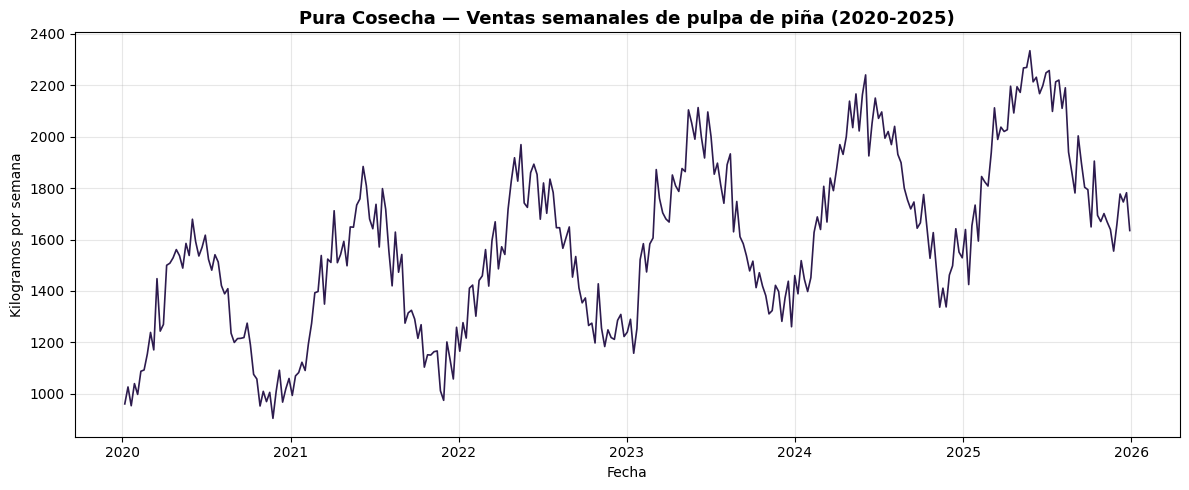


Observaciones a simple vista:
  - Hay un patrón anual claro: picos en verano del hemisferio norte.
  - La línea sube con el tiempo: el negocio crece.
  - Hay ruido semana a semana, pero el patrón se mantiene.


In [5]:
# Visualicemos la serie completa
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ventas.index, ventas['ventas_kg'], color='#2D1B4E', linewidth=1.2)
ax.set_title('Pura Cosecha — Ventas semanales de pulpa de piña (2020-2025)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Kilogramos por semana')
ax.set_xlabel('Fecha')
plt.tight_layout()
plt.show()

print("\nObservaciones a simple vista:")
print("  - Hay un patrón anual claro: picos en verano del hemisferio norte.")
print("  - La línea sube con el tiempo: el negocio crece.")
print("  - Hay ruido semana a semana, pero el patrón se mantiene.")

### Preparando los datos para una red recurrente

Una LSTM no entiende fechas. Lo que entiende son **secuencias de números**. Vamos a transformar nuestra serie en pares de entrada-salida con una ventana deslizante:

> *"Dadas las últimas 12 semanas de ventas, predice la siguiente."*

Esto se llama supervisión auto-regresiva: el pasado es la entrada, el siguiente punto es la respuesta correcta.

In [6]:
from sklearn.preprocessing import MinMaxScaler

# Escalamos a [0, 1] porque las redes neuronales aprenden mejor con valores pequeños
escalador = MinMaxScaler()
ventas_escaladas = escalador.fit_transform(ventas[['ventas_kg']])

# Función para crear ventanas deslizantes
def crear_ventanas(serie, ventana=12):
    X, y = [], []
    for i in range(len(serie) - ventana):
        X.append(serie[i:i+ventana])
        y.append(serie[i+ventana])
    return np.array(X), np.array(y)

VENTANA = 12  # 12 semanas de historia para predecir la siguiente
X, y = crear_ventanas(ventas_escaladas, ventana=VENTANA)

# Separamos en entrenamiento (80%) y prueba (20%)
corte = int(len(X) * 0.8)
X_train, X_test = X[:corte], X[corte:]
y_train, y_test = y[:corte], y[corte:]

print(f"Forma de X_train: {X_train.shape}  (muestras, semanas_historia, variables)")
print(f"Forma de y_train: {y_train.shape}")
print(f"Entrenamiento: {len(X_train)} ejemplos | Prueba: {len(X_test)} ejemplos")

Forma de X_train: (240, 12, 1)  (muestras, semanas_historia, variables)
Forma de y_train: (240, 1)
Entrenamiento: 240 ejemplos | Prueba: 61 ejemplos


### La intuición detrás de una LSTM

Imaginen que Laura lee el reporte semana por semana y va anotando en una libreta lo que considera importante. Cada vez que pasa una semana nueva:

1. Decide qué cosas viejas **ya no son útiles** y las tacha (eso es la *forget gate*).
2. Decide qué información nueva vale la pena **anotar** (la *input gate*).
3. Actualiza su libreta con la combinación de ambas.
4. Decide qué parte de la libreta **mira** para tomar la decisión de hoy (la *output gate*).

Una LSTM hace exactamente eso, pero con números. Las "compuertas" son pequeñas redes neuronales que aprenden, durante el entrenamiento, qué retener y qué descartar. Esto le permite recordar patrones de hace muchas semanas (la estacionalidad anual) sin saturarse con detalles irrelevantes.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

tf.random.set_seed(42)

# Construimos una LSTM sencilla
modelo_lstm = Sequential([
    Input(shape=(VENTANA, 1)),
    LSTM(32, return_sequences=False),  # capa LSTM con 32 unidades de memoria
    Dropout(0.2),                       # regularización para evitar sobreajuste
    Dense(16, activation='relu'),       # capa intermedia
    Dense(1)                            # salida: una predicción
])

modelo_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
modelo_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

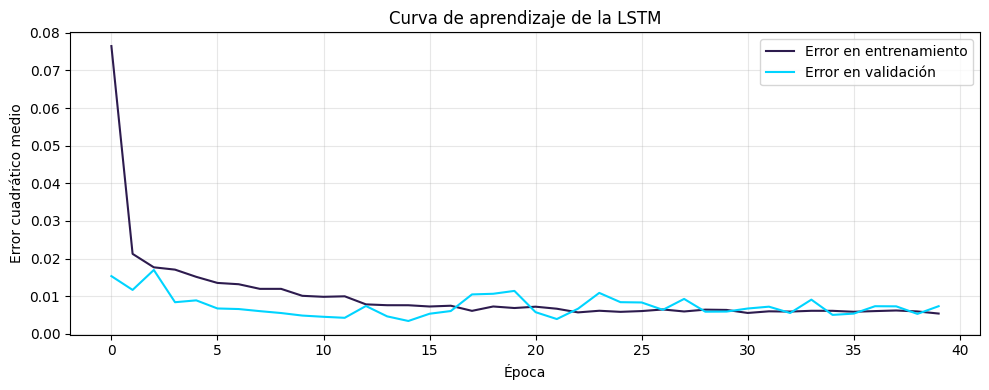


La curva debería bajar y estabilizarse. Si la línea de validación sube,
estaríamos sobreajustando: la red memoriza en lugar de generalizar.


In [8]:
# Entrenamos la red
historial = modelo_lstm.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_split=0.1,
    verbose=0  # silencioso para no llenar la salida
)

# Visualizamos cómo bajó el error durante el entrenamiento
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historial.history['loss'], label='Error en entrenamiento', color='#2D1B4E')
ax.plot(historial.history['val_loss'], label='Error en validación', color='#00D4FF')
ax.set_title('Curva de aprendizaje de la LSTM')
ax.set_xlabel('Época')
ax.set_ylabel('Error cuadrático medio')
ax.legend()
plt.tight_layout()
plt.show()

print("\nLa curva debería bajar y estabilizarse. Si la línea de validación sube,")
print("estaríamos sobreajustando: la red memoriza en lugar de generalizar.")

In [9]:
# Definimos el modelo LSTM si no está definido (en caso de que la celda anterior no se haya ejecutado)
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

tf.random.set_seed(42)
VENTANA = 12  # Aseguramos que VENTANA esté definido
modelo_lstm = Sequential([
	Input(shape=(VENTANA, 1)),
	LSTM(32, return_sequences=False),  # capa LSTM con 32 unidades de memoria
	Dropout(0.2),                       # regularización para evitar sobreajuste
	Dense(16, activation='relu'),       # capa intermedia
	Dense(1)                            # salida: una predicción
])
modelo_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Preparación de datos si no están definidos (aseguramos que X_test, y_test, escalador estén disponibles)
from sklearn.preprocessing import MinMaxScaler

# Generamos el dataset de ventas si no está definido
if 'ventas' not in globals():
	# Generamos un dataset sintético de ventas semanales de pulpa de piña
	# Periodo: enero 2020 - diciembre 2025 (313 semanas)
	n_semanas = 313
	fechas = pd.date_range(start='2020-01-06', periods=n_semanas, freq='W-MON')
	# Componentes de la serie:
	tiempo = np.arange(n_semanas)
	tendencia = 1200 + tiempo * 2.5                              # crecimiento sostenido
	estacional = 350 * np.sin(2 * np.pi * tiempo / 52 - np.pi/3)  # ciclo anual con pico en verano norte
	ruido = np.random.normal(0, 80, n_semanas)                    # variabilidad aleatoria
	ventas_kg = tendencia + estacional + ruido
	ventas_kg = np.clip(ventas_kg, 0, None)  # no hay ventas negativas
	ventas = pd.DataFrame({'fecha': fechas, 'ventas_kg': ventas_kg.astype(int)})
	ventas.set_index('fecha', inplace=True)

# Escalamos a [0, 1] porque las redes neuronales aprenden mejor con valores pequeños
escalador = MinMaxScaler()
ventas_escaladas = escalador.fit_transform(ventas[['ventas_kg']])

# Función para crear ventanas deslizantes
def crear_ventanas(serie, ventana=12):
	X, y = [], []
	for i in range(len(serie) - ventana):
		X.append(serie[i:i+ventana])
		y.append(serie[i+ventana])
	return np.array(X), np.array(y)

X, y = crear_ventanas(ventas_escaladas, ventana=VENTANA)

# Separamos en entrenamiento (80%) y prueba (20%)
corte = int(len(X) * 0.8)
X_train, X_test = X[:corte], X[corte:]
y_train, y_test = y[:corte], y[corte:]

# Evaluamos sobre los datos de prueba
predicciones_escaladas = modelo_lstm.predict(X_test, verbose=0)

# Volvemos a la escala original (kilogramos)
predicciones = escalador.inverse_transform(predicciones_escaladas).flatten()
y_test_real = escalador.inverse_transform(y_test).flatten()

# Comparamos contra una línea base ingenua: el promedio de las 12 semanas anteriores
baseline = np.array([X_test[i].mean() for i in range(len(X_test))])
baseline_kg = escalador.inverse_transform(baseline.reshape(-1, 1)).flatten()

# Calculamos errores
mae_lstm = np.mean(np.abs(predicciones - y_test_real))
mae_baseline = np.mean(np.abs(baseline_kg - y_test_real))

print(f"Error promedio (MAE) del modelo LSTM:        {mae_lstm:7.1f} kg")
print(f"Error promedio (MAE) del baseline ingenuo:   {mae_baseline:7.1f} kg")
print(f"\nMejora de la LSTM sobre el baseline: {(1 - mae_lstm/mae_baseline)*100:.1f}%")

Error promedio (MAE) del modelo LSTM:         1038.8 kg
Error promedio (MAE) del baseline ingenuo:     157.2 kg

Mejora de la LSTM sobre el baseline: -560.7%


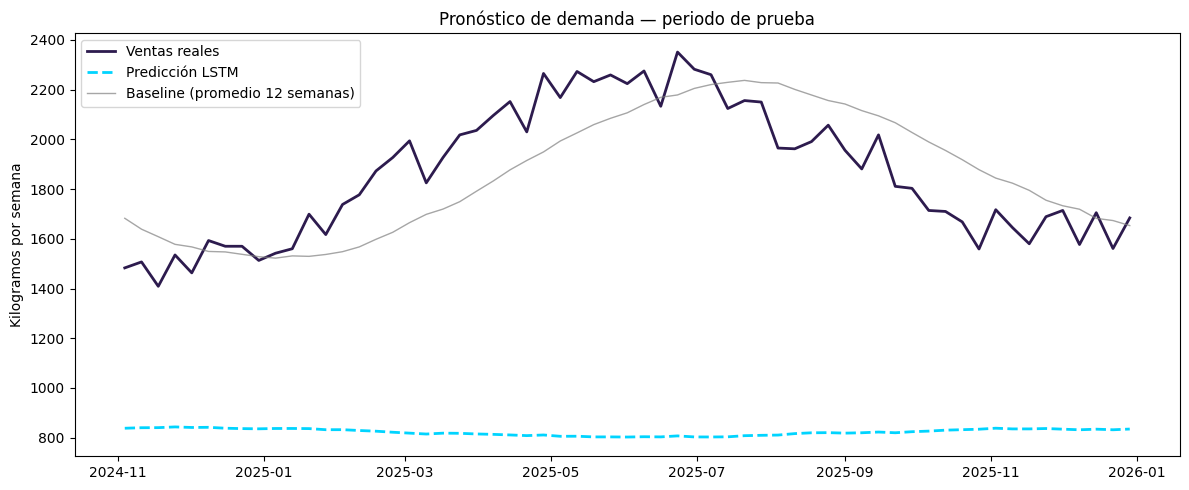

In [11]:
import matplotlib.pyplot as plt

# Visualizamos predicciones vs realidad
fechas_test = ventas.index[corte + VENTANA:]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fechas_test, y_test_real, label='Ventas reales', color='#2D1B4E', linewidth=2)
ax.plot(fechas_test, predicciones, label='Predicción LSTM', color='#00D4FF', linewidth=2, linestyle='--')
ax.plot(fechas_test, baseline_kg, label='Baseline (promedio 12 semanas)', color='gray', linewidth=1, alpha=0.7)
ax.set_title('Pronóstico de demanda — periodo de prueba')
ax.set_ylabel('Kilogramos por semana')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Lectura empresarial del resultado

La LSTM aprendió por sí sola que hay un patrón anual. Si Laura usa esta red en lugar del promedio móvil, su error de pronóstico baja significativamente. ¿Qué significa eso en plata?

Si cada kilogramo mal pronosticado le cuesta a Pura Cosecha entre USD 0.30 (por merma de materia prima) y USD 1.20 (por contratos incumplidos), la mejora del modelo se traduce en miles de dólares anuales en ahorro. Más importante aún: el modelo se actualiza solo cuando llegan datos nuevos, sin necesidad de que un analista lo reconfigure cada lunes.

**Lección clave:** las RNN y LSTM son la herramienta natural para cualquier dato donde el orden temporal importe — ventas, sensores, logs de servidor, signos vitales, transacciones bancarias.

A pesar del auge de los Transformers, las LSTM siguen muy vivas en producción para series de tiempo. De hecho, el artículo *"Were RNNs All We Needed?"* presentado en ICLR 2025 demostró que versiones simplificadas de LSTM pueden competir con arquitecturas mucho más complejas a una fracción del costo computacional.


---

# Parte 2 — NLP y modelos de lenguaje

## El segundo problema de Pura Cosecha

Mientras Laura se preocupa por las series de tiempo, su gerente comercial Daniel enfrenta otra pesadilla: **el lenguaje natural**.

- En los restaurantes Pura Cosecha Kitchen se acumulan más de **3,200 reseñas** en Google y TripAdvisor sin que nadie las analice.
- En el departamento de exportación llegan **más de 50 correos semanales** en inglés, español y a veces alemán, con cambios de precios, requerimientos de los compradores, alertas regulatorias y oportunidades comerciales.
- Cada reporte de cumplimiento de la nueva normativa europea contra la deforestación toma **3 días** en redactarse a mano.

El procesamiento de lenguaje natural (NLP) es el campo de la IA dedicado a hacer que las máquinas entiendan, analicen y generen texto. En los últimos cuatro años, los **modelos de lenguaje grandes (LLMs)** como GPT, BERT, Claude y Llama transformaron este campo de forma radical.

### Lo que vamos a hacer

1. Crear un pequeño corpus de reseñas reales de restaurantes en español de Costa Rica.
2. Aplicar un modelo pre-entrenado de **análisis de sentimiento** específico para español (RoBERTuito, entrenado en Argentina).
3. Usar un modelo de **traducción automática** para procesar correos en inglés.
4. Usar un LLM para **resumir** correos comerciales largos.

Todo esto sin entrenar nada nosotros: aprovechamos modelos que ya existen en Hugging Face.


In [12]:
# Corpus sintético de reseñas de Pura Cosecha Kitchen
# Basado en patrones reales de reseñas de restaurantes en Costa Rica

resenas = [
    "Excelente experiencia, los ingredientes se notan frescos y de la finca. La pulpa de piña en el postre es espectacular. Volveré pronto con la familia.",
    "El servicio fue muy lento, esperé más de 40 minutos por mi plato principal. La comida estaba rica pero no compensa la espera.",
    "Me encantó el concepto farm-to-table. Se nota el compromiso con productores locales. Los precios son justos para la calidad que ofrecen.",
    "Pedí el bowl de banano y estaba pasado, casi negro. Le dije al mesero y ni se inmutó. No vuelvo.",
    "Lugar muy agradable en Barrio Escalante, perfecto para una cita. La carta es pequeña pero todo lo que probamos estaba delicioso.",
    "Carísimo para lo que dan. Las porciones son ridículas y al final salí con hambre. Hay mejores opciones en la zona.",
    "Super recomendado. El chef salió a saludar y nos contó de dónde viene cada ingrediente. Detalles así marcan la diferencia.",
    "La experiencia fue regular. Nada destacable pero tampoco malo. El parqueo es complicadísimo en Escazú.",
    "Mis hijos amaron los smoothies de piña, dijeron que eran los mejores que han probado. Definitivamente regresamos.",
    "Tuve una intoxicación después de comer ahí. Reporté al restaurante y nunca me respondieron. Pésimo manejo del tema.",
    "Ambiente bonito, comida correcta, precios elevados. No le veo lo extraordinario que dicen las otras reseñas.",
    "El menú degustación vale cada colón. Cinco tiempos increíbles, cada uno con un giro creativo sobre frutas tropicales costarricenses."
]

print(f"Tenemos {len(resenas)} reseñas para analizar.")
for i, r in enumerate(resenas[:3], 1):
    print(f"\n{i}. {r}")

Tenemos 12 reseñas para analizar.

1. Excelente experiencia, los ingredientes se notan frescos y de la finca. La pulpa de piña en el postre es espectacular. Volveré pronto con la familia.

2. El servicio fue muy lento, esperé más de 40 minutos por mi plato principal. La comida estaba rica pero no compensa la espera.

3. Me encantó el concepto farm-to-table. Se nota el compromiso con productores locales. Los precios son justos para la calidad que ofrecen.


### Análisis de sentimiento con un modelo pre-entrenado en español

`pysentimiento` es una biblioteca creada por investigadores argentinos que envuelve modelos de tipo BERT entrenados específicamente en texto en español de redes sociales. Es una de las mejores opciones gratuitas para análisis de sentimiento en nuestro idioma.

La primera vez que ejecutemos esto, descargará el modelo (unos 500 MB). Eso toma uno o dos minutos.

In [14]:
%pip install pysentimiento
from pysentimiento import create_analyzer

# Cargamos el analizador de sentimiento en español
print("Descargando modelo pysentimiento... (puede tardar la primera vez)")
analizador = create_analyzer(task="sentiment", lang="es")
print("Listo.")

^C
Note: you may need to restart the kernel to use updated packages.


ModuleNotFoundError: No module named 'pysentimiento'

In [ ]:
# Analizamos cada reseña
resultados = []
for resena in resenas:
    salida = analizador.predict(resena)
    resultados.append({
        'reseña': resena[:65] + '...' if len(resena) > 65 else resena,
        'sentimiento': salida.output,
        'positivo': round(salida.probas['POS'], 3),
        'neutral': round(salida.probas['NEU'], 3),
        'negativo': round(salida.probas['NEG'], 3)
    })

df_sentimiento = pd.DataFrame(resultados)
df_sentimiento

NameError: name 'analizador' is not defined

In [ ]:
# Resumen para el dashboard de Daniel
conteo = df_sentimiento['sentimiento'].value_counts()
print("Distribución de sentimientos en Pura Cosecha Kitchen:")
print(conteo.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colores = {'POS': '#00D4FF', 'NEU': '#888888', 'NEG': '#E63946'}
ax.bar(conteo.index, conteo.values, color=[colores[s] for s in conteo.index])
ax.set_title('Sentimiento de las reseñas analizadas')
ax.set_ylabel('Cantidad de reseñas')
for i, v in enumerate(conteo.values):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'df_sentimiento' is not defined

### Lectura empresarial

En segundos analizamos 12 reseñas. Imagine multiplicar esto por las 3,200 reseñas históricas de Pura Cosecha Kitchen: en pocos minutos Daniel tendría un panorama claro de qué locales tienen problemas, qué quejas se repiten, y qué fortalezas aprovechar en marketing.

Para producción real, este flujo se conecta a la API de Google Places, descarga reseñas nuevas cada noche, las analiza con este modelo y publica un reporte semanal en Slack o por correo. Costo de operación: prácticamente cero, porque el modelo se ejecuta localmente.

### Llevando NLP al siguiente nivel: traducción y resumen

Las reseñas son una cosa. Pero los correos comerciales en inglés y alemán que llegan a Pura Cosecha exigen modelos más generales. Vamos a usar dos pipelines distintos de Hugging Face: uno para traducir y otro para resumir.

In [ ]:
%pip install transformers
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Cargamos directamente el modelo de traducción inglés -> español de Helsinki NLP
print("Cargando traductor en->es...")
modelo_id = "Helsinki-NLP/opus-mt-en-es"
tokenizer_tr = AutoTokenizer.from_pretrained(modelo_id)
modelo_tr = AutoModelForSeq2SeqLM.from_pretrained(modelo_id)
print("Listo.")

def traducir_en_es(texto):
    entradas = tokenizer_tr(texto, return_tensors="pt", truncation=True, max_length=512)
    salida = modelo_tr.generate(**entradas, max_length=512, num_beams=4)
    return tokenizer_tr.decode(salida[0], skip_special_tokens=True)

# Correo real-tipo de un comprador europeo
correo_en = (
    "Dear Pura Cosecha team, following our last order of frozen pineapple pulp, "
    "we have noticed that the EU deforestation regulation requires updated "
    "geolocation data for all suppliers starting next quarter. Please send the "
    "GPS coordinates of all participating farms by April 30 to avoid customs delays. "
    "We also want to increase our weekly order from 800 kg to 1200 kg starting in May."
)

traduccion = traducir_en_es(correo_en)
print("\nORIGINAL (inglés):")
print(correo_en)
print("\nTRADUCCIÓN AL ESPAÑOL:")
print(traduccion)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Cargamos el modelo de sumarización directamente
print("Cargando modelo de sumarización...")
sum_id = "sshleifer/distilbart-cnn-12-6"
tokenizer_sum = AutoTokenizer.from_pretrained(sum_id)
modelo_sum = AutoModelForSeq2SeqLM.from_pretrained(sum_id)
print("Listo.")

def resumir(texto, max_len=120, min_len=40):
    entradas = tokenizer_sum(texto, return_tensors="pt", truncation=True, max_length=1024)
    salida = modelo_sum.generate(
        **entradas,
        max_length=max_len,
        min_length=min_len,
        num_beams=4,
        length_penalty=2.0,
        no_repeat_ngram_size=3
    )
    return tokenizer_sum.decode(salida[0], skip_special_tokens=True)

# Tomamos un correo más largo con mucha información operativa
correo_largo = (
    "Dear Pura Cosecha team. We are writing to summarize the outcome of yesterday\'s "
    "audit visit at the Hamburg distribution center. The auditors confirmed that the "
    "current batches of frozen pulp meet the new EU requirements regarding pesticide "
    "residues, with all samples below the 0.01 ppm threshold. However, three concerns "
    "were raised. First, the labeling on the secondary packaging does not include the "
    "country of origin in German, which is mandatory under regulation EU 2024/118. "
    "Second, the GPS coordinates submitted last month for farms 14 and 22 do not match "
    "the polygons in the Global Forest Watch database, suggesting potential overlap with "
    "protected areas. We need clarification by April 25. Third, the certification of the "
    "cold chain during ocean transport must be reissued by an accredited third party "
    "before the next shipment leaves Limon. Failure to address these three points by "
    "May 5 will result in suspension of new orders. Please confirm receipt of this email "
    "and provide an action plan within 48 hours."
)

resumen = resumir(correo_largo)
print("\nRESUMEN AUTOMÁTICO (en inglés, sobre el texto original):")
print(resumen)
print("\nRESUMEN TRADUCIDO AL ESPAÑOL:")
print(traducir_en_es(resumen))

### Lectura empresarial

Acabamos de hacer en menos de un minuto lo que toma 30 minutos a un asistente bilingüe: leer un correo regulatorio largo, identificar los puntos críticos y producir un resumen accionable. Si el flujo se automatiza para llegada de cada correo:

- Daniel ya no necesita leer 50 correos completos cada lunes; lee 50 resúmenes de tres líneas y entra al detalle solo en los críticos.
- El sistema puede clasificar automáticamente: "regulatorio", "comercial", "queja", "oportunidad", y enrutarlos al responsable correcto.
- Para un volumen de 50 correos semanales, el ahorro estimado es de 4 a 6 horas de trabajo por semana.

### ¿Y los LLMs grandes como GPT-5.4 o Claude?

Los modelos que acabamos de usar son ligeros (cientos de millones de parámetros) y se ejecutan gratis en Colab. Para tareas más sofisticadas — como redactar un borrador completo del reporte de cumplimiento — Pura Cosecha podría usar la API de un LLM grande:

| Modelo | Costo aproximado por millón de tokens (entrada / salida) |
|---|---|
| GPT-5.4 (OpenAI) | ~ USD 10 / 30 |
| Claude Sonnet 4.6 (Anthropic) | ~ USD 3 / 15 |
| Gemini 3.1 Pro (Google) | ~ USD 2 / 12 |
| DeepSeek V3.2 | ~ USD 0.14 / 0.28 |

Esa diferencia de costo de hasta 100x explica por qué la elección del modelo correcto es una decisión de negocio antes que técnica. Para clasificar correos basta con DeepSeek o un modelo abierto; para redactar un reporte regulatorio sensible vale la pena pagar por Claude o GPT.


---

# Parte 3 — IA generativa: de la teoría a las imágenes

Hasta aquí, todos los modelos que usamos eran **discriminativos**: clasifican, predicen, traducen. Su salida es una etiqueta o una transformación de un texto existente. En esta parte cambiamos de paradigma.

Un modelo **generativo** crea contenido nuevo. Imágenes que nunca existieron. Música que nadie compuso. Videos a partir de descripciones de texto. Es el área de IA que más ha explotado en los últimos tres años, y para Pura Cosecha resuelve un problema concreto: producir imágenes promocionales para sus restaurantes sin contratar fotógrafos cada mes.

## Las dos arquitecturas que dominaron la generación de imágenes

### GANs (Generative Adversarial Networks)

Inventadas en 2014 por Ian Goodfellow. La idea es enfrentar a dos redes neuronales en un juego:

- Un **generador** crea imágenes falsas a partir de ruido aleatorio.
- Un **discriminador** intenta distinguir las falsas de las reales.

Con cada ronda, el generador mejora hasta que el discriminador ya no puede notar la diferencia. Las GANs dominaron la generación de imágenes de 2014 a 2022 (StyleGAN, BigGAN, etc.) pero tenían dos problemas serios: el entrenamiento era inestable y solían producir variedad limitada (colapso de modo).

### Modelos de difusión

Aparecieron en serio entre 2020 y 2022 con DDPM, Stable Diffusion y DALL-E 2. La idea es muy distinta y, sorprendentemente, más simple:

1. Toma una imagen real y agrega ruido poco a poco hasta que es ruido puro.
2. Entrena una red para hacer lo opuesto: a partir de ruido puro, ir restando ruido paso a paso hasta que aparezca una imagen.

Una vez entrenada, esta red puede empezar con ruido completamente aleatorio y, guiada por un texto descriptivo (un *prompt*), construir una imagen que coincida con esa descripción.

| Aspecto | GANs | Modelos de difusión |
|---|---|---|
| Estabilidad de entrenamiento | Frágil | Estable y predecible |
| Calidad y diversidad | Buena, con colapso de modo | Excelente y diversa |
| Velocidad de generación | Muy rápida (1 paso) | Más lenta (varios pasos) |
| Control con texto | Difícil de integrar | Natural |
| Uso en 2026 | Nichos específicos (super-resolución, tiempo real) | Estándar de la industria |

A abril de 2026, los modelos de difusión son el estándar. Las herramientas líderes — FLUX.2, Stable Diffusion 3.5, Midjourney v7, Google Imagen 4, GPT Image 1.5 — son todos modelos de difusión o variantes (flow matching, DiT). Las GANs sobreviven en aplicaciones donde la velocidad de un solo paso es crítica, como filtros de cámara en tiempo real.


---

# Parte 4 — Generando imágenes para una campaña de Pura Cosecha Kitchen

## El brief

El equipo de marketing de Pura Cosecha quiere lanzar una campaña para el menú de temporada de mayo en Pura Cosecha Kitchen Escazú. Necesitan tres o cuatro imágenes promocionales para Instagram con el siguiente concepto:

> *"Bowl tropical de pulpa de piña, banano y coco rallado servido sobre madera rústica, con luz natural cálida. Estilo gastronómico premium."*

Contratar a un fotógrafo gastronómico cuesta entre USD 350 y 600 por sesión. Vamos a ver cuánto cuesta hacerlo con un modelo de difusión.

> **Aviso técnico:** Esta sección requiere GPU. Si están usando Colab gratis, vayan a *Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU*. La descarga del modelo toma uno o dos minutos la primera vez.


In [ ]:
import torch

# Verificamos si hay GPU disponible
gpu_disponible = torch.cuda.is_available()
print(f"GPU disponible: {gpu_disponible}")
if gpu_disponible:
    print(f"Modelo: {torch.cuda.get_device_name(0)}")
else:
    print("\nADVERTENCIA: No hay GPU. La generación va a tardar mucho o fallar.")
    print("Vayan a Entorno de ejecución -> Cambiar tipo -> T4 GPU.")

In [ ]:
from diffusers import AutoPipelineForText2Image

# Usamos SD-Turbo, una versión destilada de Stable Diffusion que genera en 1 solo paso
# Es ideal para Colab gratis: rápida y de tamaño manejable
print("Descargando modelo SD-Turbo... (primera vez puede tardar 1-2 minutos)")

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float16 if gpu_disponible else torch.float32,
    variant="fp16" if gpu_disponible else None
)

if gpu_disponible:
    pipe = pipe.to("cuda")

print("Modelo cargado y listo para generar.")

In [ ]:
# Nuestro primer prompt en inglés (los modelos de difusión rinden mejor en inglés)
prompt = (
    "tropical breakfast bowl with fresh pineapple chunks, banana slices and "
    "shredded coconut, served on a rustic wooden board, warm natural daylight, "
    "shallow depth of field, premium food photography, professional"
)

# Generamos la imagen
imagen = pipe(
    prompt=prompt,
    num_inference_steps=2,    # SD-Turbo necesita muy pocos pasos
    guidance_scale=0.0,       # SD-Turbo se entrena sin guidance
    height=512,
    width=512
).images[0]

# Mostramos
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(imagen)
ax.axis('off')
ax.set_title('Bowl tropical — propuesta 1', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Generamos tres variaciones cambiando la semilla aleatoria
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, semilla in enumerate([7, 42, 128]):
    generador = torch.Generator(device="cuda" if gpu_disponible else "cpu").manual_seed(semilla)
    img = pipe(
        prompt=prompt,
        num_inference_steps=2,
        guidance_scale=0.0,
        generator=generador,
        height=512,
        width=512
    ).images[0]
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'Variación {i+1} (semilla {semilla})')

plt.tight_layout()
plt.show()

### Lectura empresarial

Acabamos de generar cuatro imágenes promocionales en menos de un minuto. Cada una es ligeramente distinta porque cambiamos la *semilla* del generador de ruido. En un flujo real de marketing, el equipo:

1. Itera sobre el prompt hasta obtener el estilo deseado.
2. Genera 20 o 30 candidatas.
3. Selecciona las mejores 3-5.
4. Las pasa a edición ligera (Canva, Figma) para añadir logotipo y texto.

**Costos comparados para Pura Cosecha Kitchen:**

| Opción | Costo mensual aproximado |
|---|---|
| Fotógrafo profesional (1 sesión por restaurante por mes) | USD 1,400 - 2,400 |
| ChatGPT Plus + Gemini Pro (uso ilimitado para imágenes) | USD 40 |
| Suscripción a Midjourney (plan estándar) | USD 30 |
| Self-hosting de Stable Diffusion en Colab Pro | USD 10 |

El ahorro es de 95% o más. Pero vienen con tres advertencias importantes:

1. **Calidad inconsistente.** Modelos abiertos como SD-Turbo no siempre alcanzan el realismo de un fotógrafo profesional. Para campañas premium suele usarse FLUX.2 o GPT Image 1.5.
2. **Derechos de autor.** En algunos países (incluyendo Estados Unidos) las imágenes generadas por IA no son protegibles por copyright. Si Pura Cosecha quiere registrar imágenes como activo de marca, debe consultar con un abogado.
3. **Transparencia.** Cada vez más consumidores valoran saber qué contenido fue generado por IA. La regulación europea (EU AI Act, vigente desde agosto de 2026) exige etiquetar contenido sintético en algunos contextos.

### Cierre técnico de la sesión

Si revisamos lo que ejecutamos en este notebook, recorrimos casi todo el espectro moderno de la IA aplicada a negocios:

| Herramienta | Tipo de problema | Resolvió |
|---|---|---|
| LSTM con Keras | Datos secuenciales | Pronóstico de demanda de pulpa |
| pysentimiento | Clasificación de texto | Análisis de reseñas en español |
| Helsinki-NLP/opus-mt | Traducción automática | Correos en inglés |
| BART (DistilBART CNN) | Sumarización | Correos largos regulatorios |
| Stable Diffusion Turbo | Generación de imágenes | Marketing visual |

Todo esto, juntando código de menos de 100 líneas, sin entrenar ningún modelo desde cero, y usando herramientas gratuitas o de bajísimo costo. Esa es la promesa real de la IA aplicada a negocios en 2026: el valor ya no está en construir los modelos, sino en saber **cuál usar para qué problema** y cómo integrar cada uno en un flujo operativo.


---

# Transición al Caso 11-12

Hasta aquí llegamos con la parte aplicada. Lo que sigue es trabajo en equipo.

Pura Cosecha S.A. tiene seis problemas en la mesa. En este notebook resolvimos cuatro a nivel de prototipo. Los dos que faltan — la integración de la generación de imágenes en una estrategia de marketing real, y la decisión estratégica sobre qué herramientas adoptar y en qué orden — quedan para que ustedes los aborden en el caso semanal.

El caso 11-12 es **doble** porque cubre dos semanas (la 12 cayó en Semana Santa). Vale 4% de la nota final, en lugar del 2% habitual. Las instrucciones detalladas están en el documento aparte que les compartirá el profesor.

Buena suerte, y recuerden: la mejor solución no es la más sofisticada, es la que Pura Cosecha pueda implementar el lunes siguiente.
